In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("seeds.csv")
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [ ]:
df.describe()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,1.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,0.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,0.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,1.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,2.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   kernel_length          210 non-null    float64
 4   kernel_width           210 non-null    float64
 5   asymmetry_coefficient  210 non-null    float64
 6   groove_length          210 non-null    float64
 7   species                210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


array([[<Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'perimeter'}>,
        <Axes: title={'center': 'compactness'}>],
       [<Axes: title={'center': 'kernel_length'}>,
        <Axes: title={'center': 'kernel_width'}>,
        <Axes: title={'center': 'asymmetry_coefficient'}>],
       [<Axes: title={'center': 'groove_length'}>,
        <Axes: title={'center': 'species'}>, <Axes: >]], dtype=object)

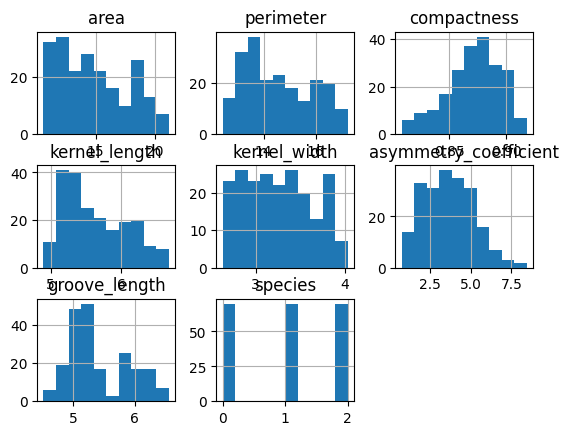

In [ ]:
df.hist()

In [ ]:
df.sample(10)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
88,21.18,17.21,0.8989,6.573,4.033,5.780,6.231,1
35,16.12,15.00,0.9000,5.709,3.485,2.270,5.443,0
123,18.43,15.97,0.9077,5.980,3.771,2.984,5.905,1
202,11.18,12.72,0.8680,5.009,2.810,4.051,4.828,2
52,14.49,14.61,0.8538,5.715,3.113,4.116,5.396,0
167,12.15,13.45,0.8443,5.417,2.837,3.638,5.338,2
165,12.10,13.15,0.8793,5.105,2.941,2.201,5.056,2
158,11.75,13.52,0.8082,5.444,2.678,4.378,5.310,2
151,12.01,13.52,0.8249,5.405,2.776,6.992,5.270,2
106,18.85,16.17,0.9056,6.152,3.806,2.843,6.200,1


In [ ]:
scaledFeatures = MinMaxScaler().fit_transform(df.iloc[:, 0:7])
labels = df.species

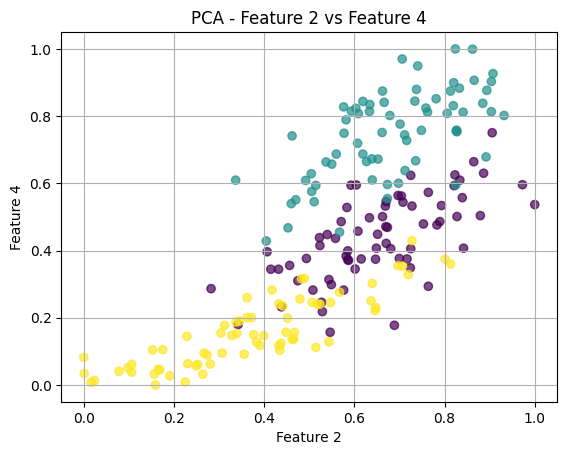

In [ ]:
plt.scatter(scaledFeatures[:, 2], scaledFeatures[:, 4], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('Feature 2')
plt.ylabel('Feature 4')
plt.title('PCA - Feature 2 vs Feature 4')
plt.grid(True)

In [ ]:
pca = PCA(n_components=2).fit(scaledFeatures)
reducedFeatures = pca.transform(scaledFeatures)
reducedFeatures[0:10]

array([[ 0.07502933,  0.12969116],
       [-0.02430059,  0.36411968],
       [-0.14937464,  0.45649725],
       [-0.18088051,  0.44055742],
       [ 0.25058879,  0.44129658],
       [-0.11363851,  0.36902075],
       [-0.04378114,  0.10966172],
       [-0.13412921,  0.31501281],
       [ 0.43988919,  0.00147033],
       [ 0.35028428,  0.18923482]])

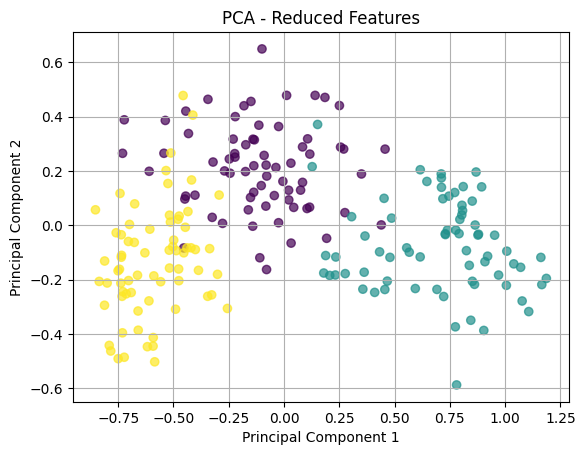

In [ ]:
plt.scatter(reducedFeatures[:, 0], reducedFeatures[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Reduced Features')
plt.grid(True)

In [ ]:
pca.explained_variance_ratio_

array([0.78903362, 0.1290949 ])

In [ ]:
PCA(n_components=3).fit(scaledFeatures).explained_variance_ratio_

array([0.78903362, 0.1290949 , 0.06866698])

[Text(1, 0, '$PC_1$'),
 Text(2, 0, '$PC_2$'),
 Text(3, 0, '$PC_3$'),
 Text(4, 0, '$PC_4$'),
 Text(5, 0, '$PC_5$'),
 Text(6, 0, '$PC_6$'),
 Text(7, 0, '$PC_7$')]

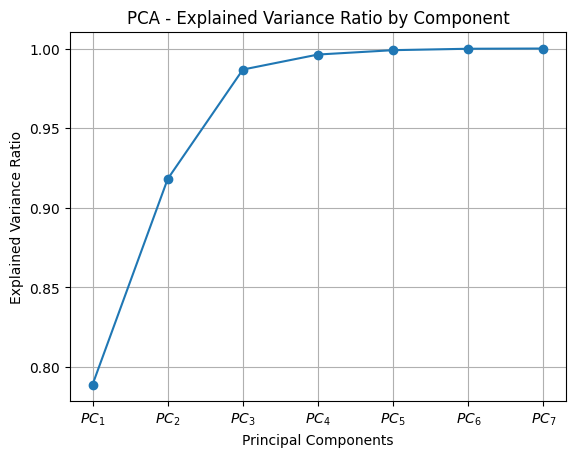

In [ ]:
evr = PCA(n_components=7).fit(scaledFeatures).explained_variance_ratio_
plt.plot(range(1, 8), np.cumsum(evr), marker='o')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Explained Variance Ratio by Component')
plt.grid(True)
plt.gca().set_xticks(range(1, 8))
plt.gca().set_xticklabels([r'$PC_1$', r'$PC_2$', r'$PC_3$', r'$PC_4$', r'$PC_5$', r'$PC_6$', r'$PC_7$'])

In [ ]:
from sklearn.datasets import  load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

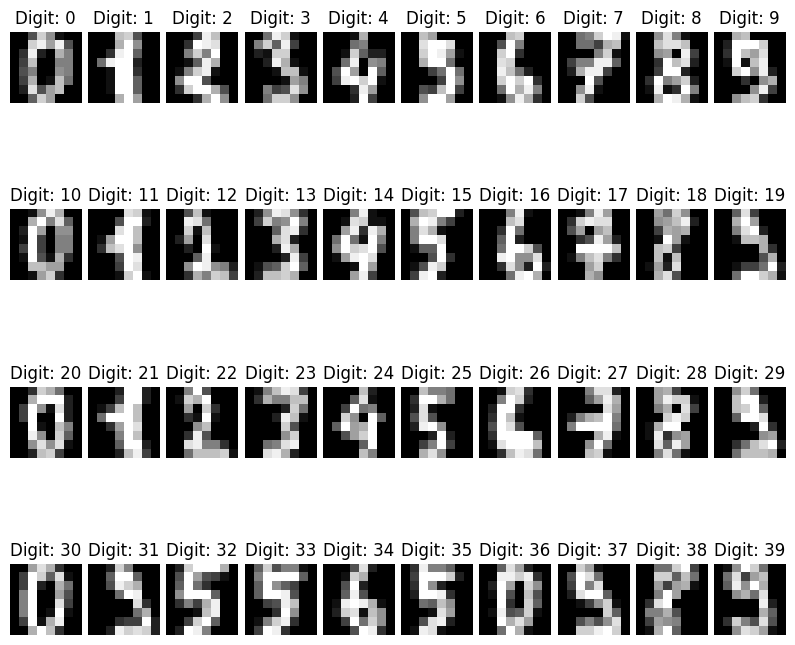

In [ ]:
def plot_digits(data):
    fig, ax = plt.subplots(4, 10, figsize=(10, 9),subplot_kw={'xticks':[], 'yticks':[]},gridspec_kw=dict(hspace=0.1,wspace=0.1))
    for i , ax in enumerate(ax.flat):
        ax.imshow(data[i].reshape(8, 8), cmap='gray', interpolation='nearest', clim=(0, 16))
        ax.set_title(f'Digit: {i}')
        ax.axis('off')
plot_digits(digits.data)

In [ ]:
pca = PCA(2)
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


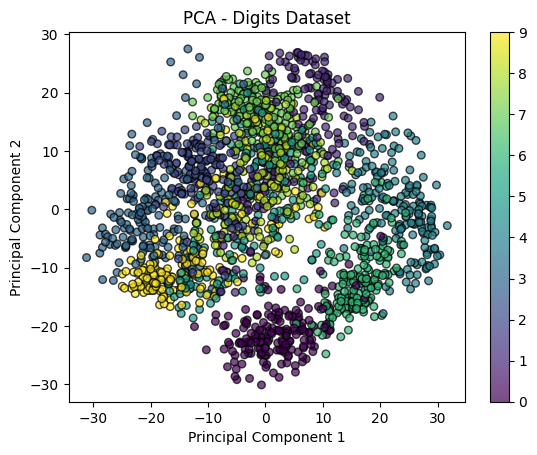

In [ ]:
plt.scatter(projected[:, 0], projected[:, 1], c=digits.target, cmap='viridis', edgecolor='k', s=30 , alpha=0.7)
plt.colorbar()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Digits Dataset')
plt.show()

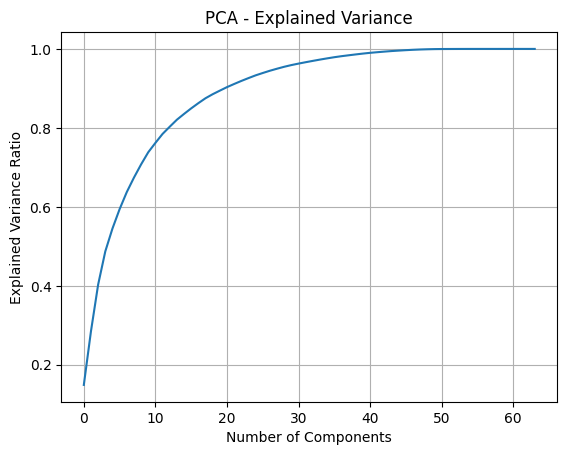

In [ ]:
pca = PCA().fit(digits.data)
evr = np.cumsum(pca.explained_variance_ratio_)
plt.plot(evr)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Explained Variance')
plt.grid()
plt.show()

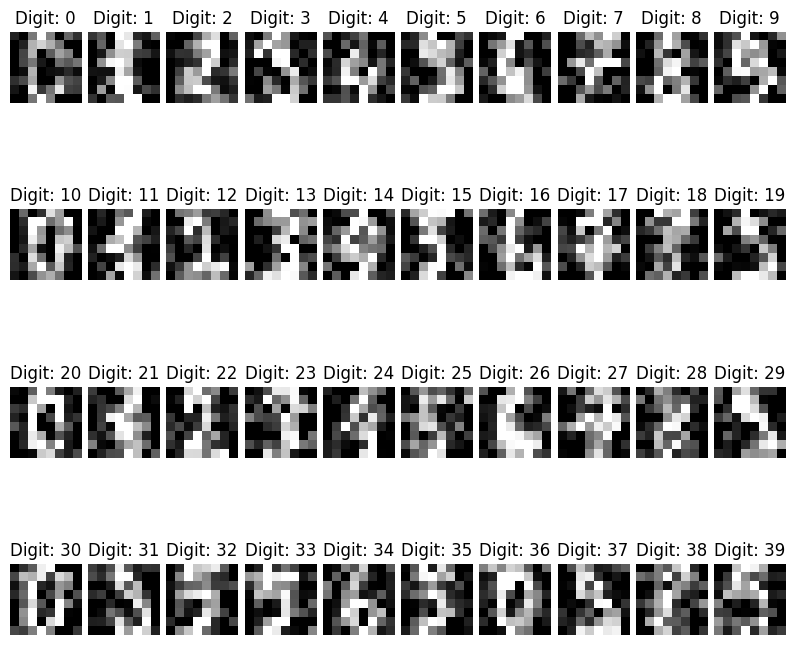

In [ ]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

In [ ]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

np.int64(12)

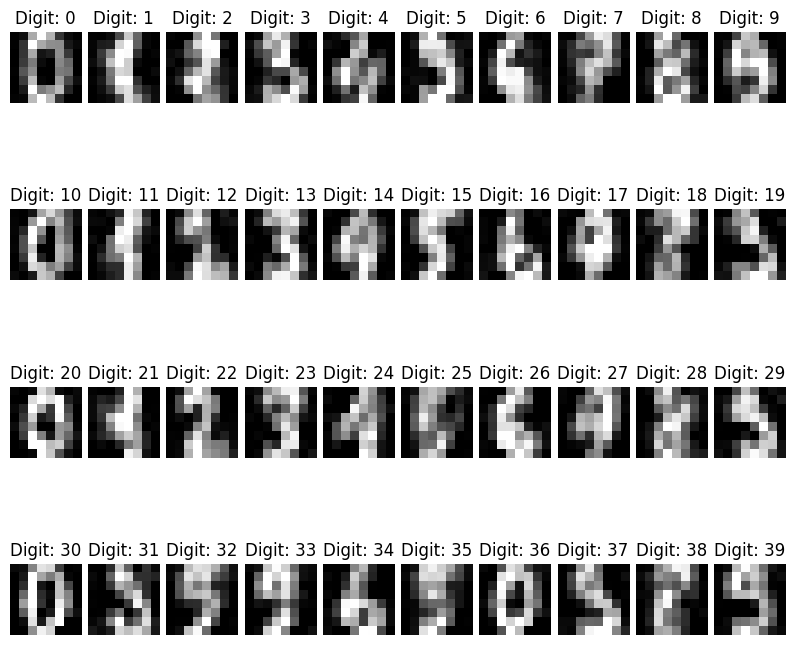

In [ ]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)